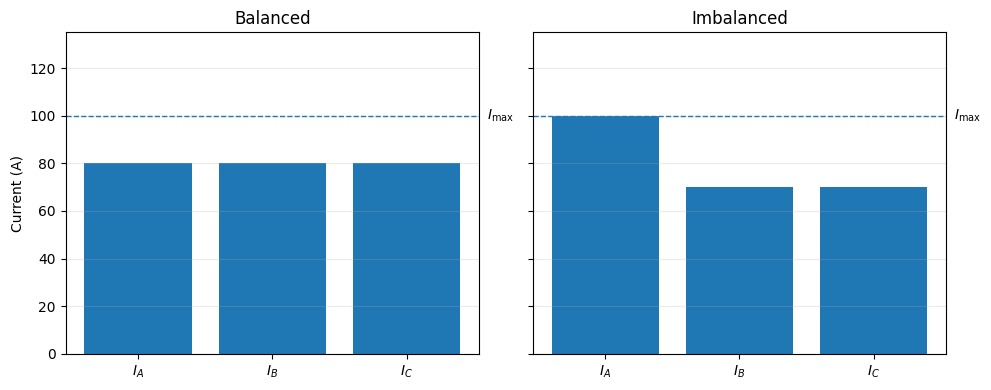

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def neutral_current(Ia, Ib, Ic):
    """
    Neutral current magnitude from 3 phase currents assumed 120° apart.
    (Simple phasor sum: In = |Ia∠0 + Ib∠-120 + Ic∠+120|)
    """
    angles = np.deg2rad([0, -120, 120])
    I = np.array([Ia, Ib, Ic]) * np.exp(1j * angles)
    return float(np.abs(I.sum()))

# -----------------------------
# Edit these numbers as needed
# -----------------------------
Imax = 100.0                      # phase current limit (A)
I_bal = np.array([80, 80, 80.0])  # balanced example (same total as imbalanced)
I_imb = np.array([100, 70, 70.0]) # imbalanced example (one phase hits the limit)

# Stranded capacity (how much extra total current you *could* carry if perfectly balanced)
nameplate_total = 3 * Imax
usable_total_at_imbalance = I_imb.sum()
stranded_A = nameplate_total - usable_total_at_imbalance
stranded_pct = 100 * stranded_A / nameplate_total

# Loss/neutral indicators for the small inset (illustrative)
In_bal = neutral_current(*I_bal)
In_imb = neutral_current(*I_imb)
phase_loss_bal = np.sum(I_bal**2)
phase_loss_imb = np.sum(I_imb**2)
phase_loss_increase_pct = 100 * (phase_loss_imb / phase_loss_bal - 1)

# -----------------------------
# Plot
# -----------------------------
labels = [r"$I_A$", r"$I_B$", r"$I_C$"]
x = np.arange(3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

def draw_panel(ax, currents, title, shade_unused=False):
    bars = ax.bar(x, currents)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.35 * Imax)
    ax.grid(axis="y", alpha=0.25)

    # Phase limit line
    ax.axhline(Imax, linestyle="--", linewidth=1)
    ax.text(2.6, Imax, r"$I_{\max}$", va="center", ha="left")

    if shade_unused:
        # Shade unused headroom above bars up to Imax
        for b in bars:
            h = b.get_height()
            if h < Imax:
                ax.add_patch(
                    Rectangle(
                        (b.get_x(), h),
                        b.get_width(),
                        Imax - h,
                        facecolor="k",
                        alpha=0.08,
                        edgecolor="none",
                    )
                )

        # Bracket-style annotation across phases showing "stranded capacity"
        



# Left: balanced
draw_panel(axes[0], I_bal, "Balanced")
axes[0].set_ylabel("Current (A)")

# Right: imbalanced
draw_panel(axes[1], I_imb, "Imbalanced", shade_unused=False)

# Small inset with formula + example numbers (kept compact)


fig.tight_layout()

plt.show()


C:\Users\Notandi\AppData\Local\Temp\ipykernel_19688\2087381999.py:93: RuntimeWarning: invalid value encountered in divide
  cur = np.where(denom > 0, (num_cur / denom) * 100.0, 0.0)
C:\Users\Notandi\AppData\Local\Temp\ipykernel_19688\2087381999.py:97: RuntimeWarning: invalid value encountered in divide
  cur_dev = np.where(denom > 0, (num_dev / denom) * 100.0, 0.0)


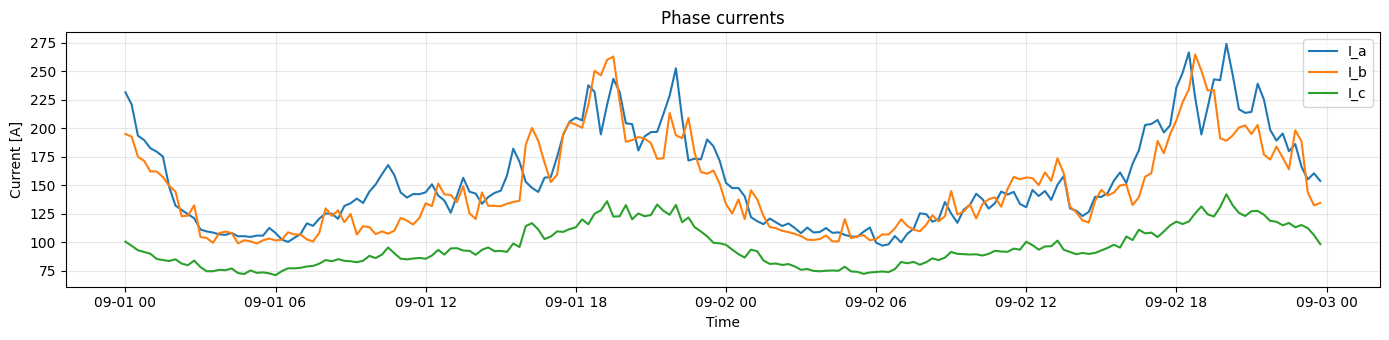

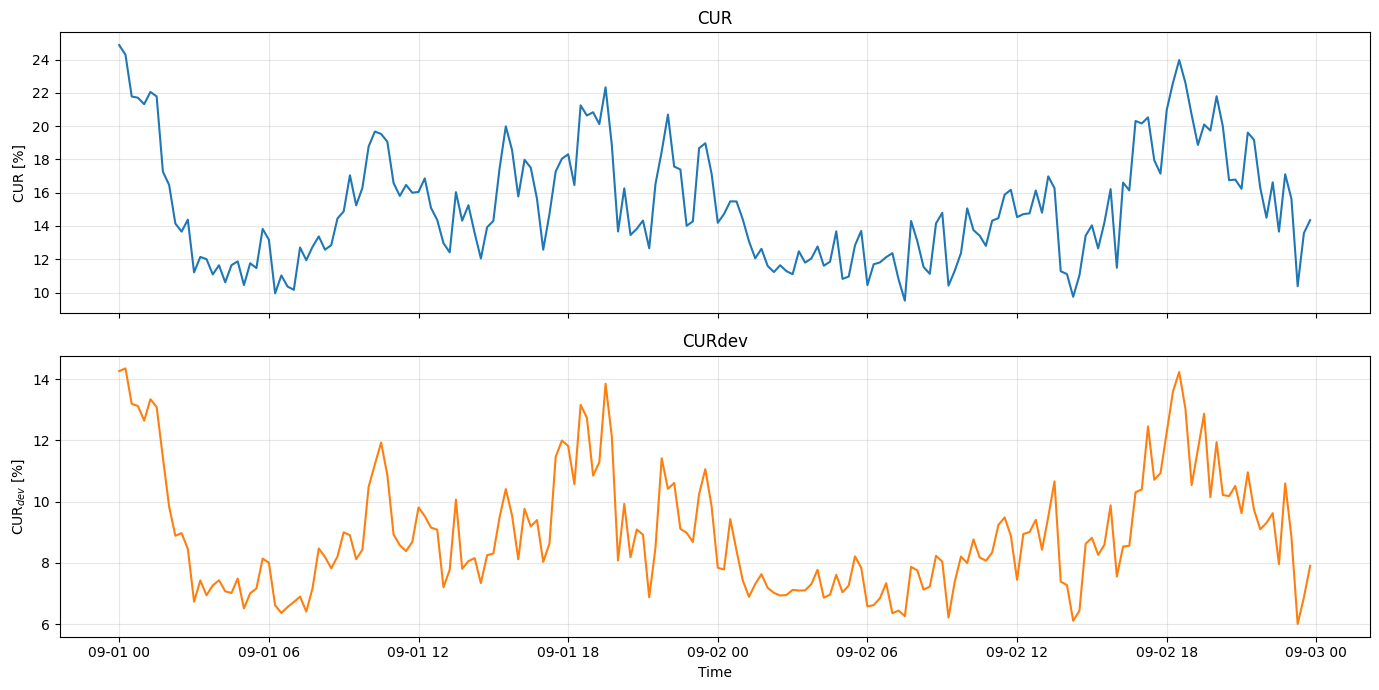

              CUR     CUR_dev
count  192.000000  192.000000
mean    15.203199    8.937930
std      3.429844    1.934130
min      9.515762    6.006262
50%     14.462172    8.481059
90%     20.294472   11.916480
95%     21.737363   13.056130
99%     23.995623   14.234767
max     24.864777   14.349740


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math

FREQ = pd.Timedelta(minutes=15)


def cur_ratio(ia: float, ib: float, ic: float) -> float:
    denom = abs(ia) + abs(ib) + abs(ic)
    if denom == 0:
        return 0.0
    numerator = max(abs(ia - ib), abs(ia - ic), abs(ib - ic))
    return (numerator / denom) * 100.0


def cur_dev_ratio(ia: float, ib: float, ic: float) -> float:
    denom = abs(ia) + abs(ib) + abs(ic)
    if denom == 0:
        return 0.0
    i_avg = (ia + ib + ic) / 3.0
    numerator = max(abs(ia - i_avg), abs(ib - i_avg), abs(ic - i_avg))
    return (numerator / denom) * 100.0


def parse_dnr(d):
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")
    if digits == "":
        return None
    return int(digits)


def make_expected_grid(df, freq=FREQ):
    out = []
    for (sid, tr), g in df.groupby(["substation_id", "transformer"]):
        t0 = g["ts"].min()
        t1 = g["ts"].max()
        grid = pd.date_range(t0, t1, freq=freq)
        out.append(pd.DataFrame({"substation_id": sid, "transformer": tr, "ts": grid}))
    return pd.concat(out, ignore_index=True)


# -----------------------------
# Load + align Janitza currents
# -----------------------------
jn_current_path = "../data/all_substations_current_202508-202511.parquet"
df_jn_current = pd.read_parquet(jn_current_path)

df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(parse_dnr)
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)

tol = pd.Timedelta(seconds=10)
ts_raw = df_jn_current["ts"]
t_floor = ts_raw.dt.floor("15min")
offset = ts_raw - t_floor
df_jn_current["ts"] = t_floor.where(offset <= tol, ts_raw.dt.ceil("15min"))

num_cols = ["I_a", "I_b", "I_c", "I_total"]
df_jn_current = (
    df_jn_current
    .groupby(["substation_id", "ts", "transformer"], as_index=False)[num_cols]
    .mean()
)

grid = make_expected_grid(df_jn_current, freq=FREQ)
jn_bins = df_jn_current[["substation_id", "ts", "transformer"]].drop_duplicates()

grid = grid.merge(
    jn_bins.assign(jn_present=1),
    on=["substation_id", "ts", "transformer"],
    how="left"
)
grid["jn_present"] = grid["jn_present"].fillna(0).astype(int)

good_bins = grid[grid["jn_present"] == 1][["substation_id", "ts", "transformer"]]
df_jn_current = df_jn_current.merge(good_bins, on=["substation_id", "ts", "transformer"], how="inner")


# -----------------------------
# Compute CUR and CUR_dev
# -----------------------------
ia = df_jn_current["I_a"].to_numpy(dtype=float)
ib = df_jn_current["I_b"].to_numpy(dtype=float)
ic = df_jn_current["I_c"].to_numpy(dtype=float)

denom = np.abs(ia) + np.abs(ib) + np.abs(ic)

num_cur = np.maximum.reduce([np.abs(ia - ib), np.abs(ia - ic), np.abs(ib - ic)])
cur = np.where(denom > 0, (num_cur / denom) * 100.0, 0.0)

i_avg = (ia + ib + ic) / 3.0
num_dev = np.maximum.reduce([np.abs(ia - i_avg), np.abs(ib - i_avg), np.abs(ic - i_avg)])
cur_dev = np.where(denom > 0, (num_dev / denom) * 100.0, 0.0)

df_jn_current["CUR"] = cur
df_jn_current["CUR_dev"] = cur_dev


# -----------------------------
# Select pair + optional time window + plot
# -----------------------------
SID = 1416       # <-- set this 1416 sp1
TR = "sp1"      # <-- set this (must match df_jn_current["transformer"])

# Optional: set to None to plot full available span
T_START = "2025-09-01 00:00:00"   # <-- set this or None
T_END   = "2025-09-02 23:45:00"   # <-- set this or None

df_pair = df_jn_current[
    (df_jn_current["substation_id"] == SID) &
    (df_jn_current["transformer"] == TR)
].copy()



if df_pair.empty:
    print("No data found for this (substation_id, transformer). Try checking available values:")
    print("substation_id examples:", sorted(df_jn_current["substation_id"].dropna().unique())[:20])
    print("transformer examples:", df_jn_current["transformer"].dropna().unique()[:20])
else:
    df_pair = df_pair.sort_values("ts")

    # Apply time filter if provided
    if T_START is not None:
        t0 = pd.to_datetime(T_START)
        df_pair = df_pair[df_pair["ts"] >= t0]
    if T_END is not None:
        t1 = pd.to_datetime(T_END)
        df_pair = df_pair[df_pair["ts"] <= t1]

    if df_pair.empty:
        print("No data left after applying the time window. Check T_START/T_END.")
        print("Available span:",
              df_jn_current.loc[
                  (df_jn_current["substation_id"] == SID) & (df_jn_current["transformer"] == TR),
                  "ts"
              ].min(),
              "to",
              df_jn_current.loc[
                  (df_jn_current["substation_id"] == SID) & (df_jn_current["transformer"] == TR),
                  "ts"
              ].max()
        )
    else:
        fig, ax = plt.subplots(figsize=(14, 3.5))
        ax.plot(df_pair["ts"], df_pair["I_a"], label="I_a")
        ax.plot(df_pair["ts"], df_pair["I_b"], label="I_b")
        ax.plot(df_pair["ts"], df_pair["I_c"], label="I_c")
        ax.set_title(f"Phase currents")
        ax.set_ylabel("Current [A]")
        ax.set_xlabel("Time")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

        axs[0].plot(df_pair["ts"], df_pair["CUR"])
        axs[0].set_ylabel("CUR [%]")
        axs[0].set_title(f"CUR")
        axs[0].grid(True, alpha=0.3)

        # Set color to "tab:orange" for the second plot
        axs[1].plot(df_pair["ts"], df_pair["CUR_dev"], color="tab:orange")
        axs[1].set_ylabel(r"CUR$_{dev}$ [%]")
        axs[1].set_title(f"CURdev")
        axs[1].set_xlabel("Time")
        axs[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Optional: quick summary
        print(df_pair[["CUR", "CUR_dev"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
